# Media Bias Detection in News Headlines

## 1. Project Overview

This project focuses on detecting media bias in news headlines using Natural Language Processing (NLP) and Machine Learning.

The objective is to classify headlines into three categories:

* **Left** – synthetic headlines using framing patterns associated with left-leaning perspectives
* **Neutral** – primarily factual and descriptive headlines with minimal ideological framing
* **Right** – synthetic headlines using framing patterns associated with right-leaning perspectives

The dataset used in this project is synthetically generated for experimentation and demonstration. The labels represent predefined framing patterns and should not be interpreted as objective political classifications.

### Technology Stack

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn
* Sentence-BERT (SBERT)
* HuggingFace Transformers

### Workflow

1. Dataset Collection / Generation
2. Data Cleaning and Preprocessing
3. Exploratory Data Analysis (EDA)
4. Text Representation using SBERT
5. Baseline Machine Learning Models
6. Transformer Fine-Tuning
7. Model Evaluation
8. Model Comparison
9. Sample Predictions


## 2. Import Libraries and Load Dataset


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display more text in DataFrames
pd.set_option("display.max_colwidth", 200)

# Load dataset
df = pd.read_csv("media_bias_headlines.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


### 2.1 Initial Dataset Inspection

Before preprocessing the text, we inspect the structure, size, columns, and sample records of the dataset.


In [6]:
# Dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Column names
print("\nColumns:")
print(df.columns.tolist())

# First 5 records
df.head()

Number of rows: 5000
Number of columns: 3

Columns:
['id', 'headline', 'label']


,id,headline,label
0,1,An international panel to fund sovereignty safeguards in international agreements at a Brussels conference,right
1,2,The food safety agency to audit agricultural census methods as the fiscal year begins,neutral
2,3,Free legal clinics debated by the mayor's office this winter,left
3,4,The homeland security department to renew cooperation agreements between local police and federal agents in Seattle,right
4,5,A city council member says the transportation agency will reduce bus route timetables in the coming fiscal year,neutral


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        5000 non-null   int64 
 1   headline  5000 non-null   object
 2   label     5000 non-null   object
dtypes: int64(1), object(2)
memory usage: 117.3+ KB


In [10]:
df.describe(include="all")

,id,headline,label
count,5000.000000,5000,5000
unique,NaN,5000,3
top,NaN,An international panel to fund sovereignty safeguards in international agreements at a Brussels conference,right
freq,NaN,1,1667
mean,2500.500000,NaN,NaN
std,1443.520003,NaN,NaN
min,1.000000,NaN,NaN
25%,1250.750000,NaN,NaN
50%,2500.500000,NaN,NaN
75%,3750.250000,NaN,NaN


In [12]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
id          0
headline    0
label       0
dtype: int64


In [14]:
print("Duplicate headlines:", df["headline"].duplicated().sum())
print("Duplicate IDs:", df["id"].duplicated().sum())

Duplicate headlines: 0
Duplicate IDs: 0


In [16]:
print("Class distribution:")
print(df["label"].value_counts())

Class distribution:
label
right      1667
left       1667
neutral    1666
Name: count, dtype: int64


In [18]:
print("\nClass distribution (%):")
print(
    (df["label"].value_counts(normalize=True) * 100)
    .round(2)
)


Class distribution (%):
label
right      33.34
left       33.34
neutral    33.32
Name: proportion, dtype: float64


In [20]:
for label in ["left", "neutral", "right"]:
    print(f"\n===== {label.upper()} =====")
    display(df[df["label"] == label][["headline", "label"]].sample(5, random_state=42))


===== LEFT =====


,headline,label
2792,Should military planners delay protections for whistleblowers ahead of talks in Vienna?,left
2956,The housing authority to revisit rent stabilization measures,left
1202,City planners examine clean air standards for industrial plants under a $685 million spending plan,left
2179,9 regional agencies to roll back accessible sidewalks and ramps after weeks of testimony,left
4848,A legislative elections committee to study polling places in underserved areas in New England this year,left



===== NEUTRAL =====


,headline,label
2849,An AI oversight office backs AI procurement standards for governments ahead of the spring session,neutral
2985,State motor vehicle officials to study train maintenance windows ahead of the spring session,neutral
1269,A city council member confirms a panel of 9 lawmakers will weigh licensing rules for telehealth providers after a lengthy committee session,neutral
2205,A senior state official says city planners prioritized construction start deadlines for new lots,neutral
4861,A panel of 11 lawmakers funded retail sales data releases,neutral



===== RIGHT =====


,headline,label
2823,State agriculture officials boosted tax relief for farm families before the July deadline,right
2946,Border patrol staffing reduced by the homeland security department,right
1198,Energy export terminals examined by energy analysts next year,right
2116,Why did the energy department curb gas tax relief for drivers in New England and Seattle?,right
4803,Diplomats revisit sanctions on hostile governments as the fiscal year begins,right


### 2.2 Headline Quality Inspection

Since this is a text classification project, the quality and uniqueness of the headlines are important. We check for unusually short headlines, duplicate records, and potentially malformed text before proceeding with preprocessing.

In [23]:
# Check headline lengths
df["word_count"] = df["headline"].str.split().str.len()

print("Minimum words:", df["word_count"].min())
print("Maximum words:", df["word_count"].max())
print("Average words:", round(df["word_count"].mean(), 2))

# Show very short headlines
print("\nVery short headlines:")
display(
    df[df["word_count"] < 8][["headline", "label"]].head(20)
)

Minimum words: 8
Maximum words: 23
Average words: 12.68

Very short headlines:


,headline,label


In [25]:
# Inspect headlines containing potentially awkward "to + verb" constructions
mask = df["headline"].str.contains(
    r"\b(the|a|an|department|agency|officials|board|committee).*\bto\s+\w+",
    case=False,
    regex=True
)

print("Potentially awkward headlines:", mask.sum())

display(
    df.loc[mask, ["headline", "label"]].head(20)
)

Potentially awkward headlines: 1034


C:\Users\Arpitha\AppData\Local\Temp\ipykernel_1348\3393921193.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df["headline"].str.contains(


,headline,label
0,An international panel to fund sovereignty safeguards in international agreements at a Brussels conference,right
1,The food safety agency to audit agricultural census methods as the fiscal year begins,neutral
3,The homeland security department to renew cooperation agreements between local police and federal agents in Seattle,right
7,The transit authority to study ride-hailing operating flexibility before the April deadline,right
14,Plan to revisit guidelines for AI use in agencies heads to a public hearing,neutral
19,A panel of 3 lawmakers outlines plan to review emergency alert testing schedules,neutral
23,17 county boards to study state revenue reporting rules after a lengthy committee session,neutral
31,State budget officials to study job-creating public works spending in the coming fiscal year,left
33,A welfare reform panel to expand private charity tax credits under a $386 million spending plan,right
39,The wage commission to expand right-to-work protections following a public consultation,right


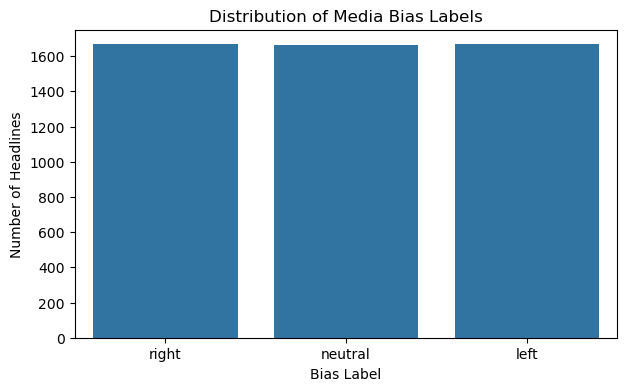

In [27]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Distribution of Media Bias Labels")
plt.xlabel("Bias Label")
plt.ylabel("Number of Headlines")

plt.show()

In [29]:
# Check for obvious malformed patterns

bad_patterns = [
    r"\bheads to\b",
    r"\bto\s+\w+\s+to\s+\w+",
    r"\bplan to\b.*\bheads\b",
    r"\bto\s+\w+\s+\w+\s+to\s+\w+"
]

for pattern in bad_patterns:
    matches = df[df["headline"].str.contains(
        pattern,
        case=False,
        regex=True,
        na=False
    )]

    print(f"\nPattern: {pattern}")
    print("Matches:", len(matches))

    if len(matches) > 0:
        display(matches[["headline", "label"]].head(10))


Pattern: \bheads to\b
Matches: 34


,headline,label
14,Plan to revisit guidelines for AI use in agencies heads to a public hearing,neutral
329,Plan to audit arbitration procedures heads to a public hearing starting in September,neutral
396,Plan to review union organizing protections heads to a public hearing across Nashville,left
525,Plan to revisit bike lanes and pedestrian paths heads to a public hearing starting in March,left
623,Plan to audit evidence disclosure timelines heads to a public hearing after months of debate,neutral
813,Plan to study language classes for newly arrived families heads to a public hearing during a Monday hearing,left
977,Plan to revisit universal access to city services heads to a public hearing in the coming fiscal year,left
1022,Plan to track early voting access heads to a public hearing following a closed-door meeting,left
1239,Plan to track cost-benefit reviews of environmental rules heads to a public hearing following a public consultation,right
1405,Plan to revisit multilateral peace talks heads to a public hearing after a two-year review,left



Pattern: \bto\s+\w+\s+to\s+\w+
Matches: 0

Pattern: \bplan to\b.*\bheads\b
Matches: 34


,headline,label
14,Plan to revisit guidelines for AI use in agencies heads to a public hearing,neutral
329,Plan to audit arbitration procedures heads to a public hearing starting in September,neutral
396,Plan to review union organizing protections heads to a public hearing across Nashville,left
525,Plan to revisit bike lanes and pedestrian paths heads to a public hearing starting in March,left
623,Plan to audit evidence disclosure timelines heads to a public hearing after months of debate,neutral
813,Plan to study language classes for newly arrived families heads to a public hearing during a Monday hearing,left
977,Plan to revisit universal access to city services heads to a public hearing in the coming fiscal year,left
1022,Plan to track early voting access heads to a public hearing following a closed-door meeting,left
1239,Plan to track cost-benefit reviews of environmental rules heads to a public hearing following a public consultation,right
1405,Plan to revisit multilateral peace talks heads to a public hearing after a two-year review,left



Pattern: \bto\s+\w+\s+\w+\s+to\s+\w+
Matches: 5


,headline,label
182,A panel of 11 lawmakers outlines a plan to reduce alternatives to arrest for minor offenses next year,left
805,Plan to fund alternatives to arrest for minor offenses clears a key hurdle ahead of a key vote,left
2215,State lawmakers to curb pathways to citizenship for long-term residents following a closed-door meeting,left
2483,County officials to delay alternatives to arrest for minor offenses in Phoenix and Colorado,left
3540,The visa office to review pathways to citizenship for long-term residents,left


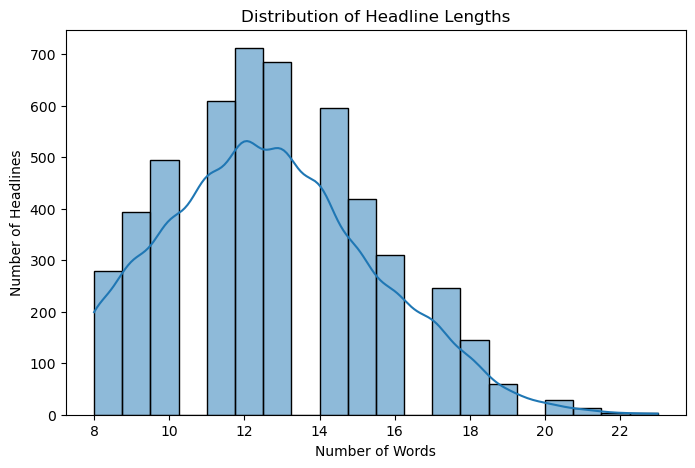

In [31]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="word_count",
    bins=20,
    kde=True
)

plt.title("Distribution of Headline Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Headlines")

plt.show()

In [33]:
print(df["word_count"].describe())

count    5000.000000
mean       12.683600
std         2.758952
min         8.000000
25%        11.000000
50%        13.000000
75%        14.000000
max        23.000000
Name: word_count, dtype: float64


In [35]:
# Remove the 34 clearly malformed synthetic headlines
bad_mask = df["headline"].str.contains(
    r"\bheads to\b",
    case=False,
    regex=True,
    na=False
)

print("Malformed headlines found:", bad_mask.sum())

# Remove them
df = df[~bad_mask].copy()

print("Dataset size after cleaning:", len(df))

Malformed headlines found: 34
Dataset size after cleaning: 4966


In [37]:
df.drop(columns=["word_count"], inplace=True)

In [39]:
df.to_csv("media_bias_headlines_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the characteristics of the cleaned news headline dataset.

The analysis focuses on:
- Distribution of the three bias labels
- Headline length across different labels
- Frequently occurring words
- Word associations across bias categories

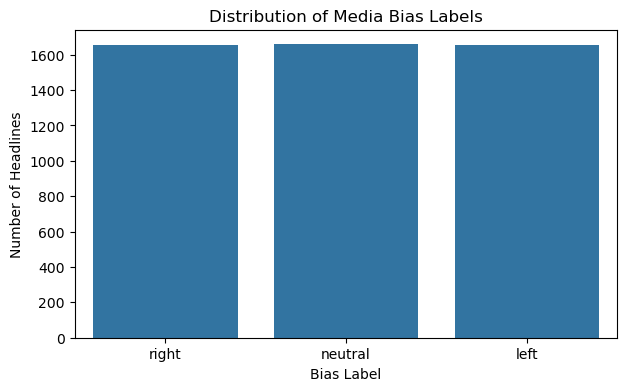

In [55]:
#3.1 Bias Label Distribution
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="label")

plt.title("Distribution of Media Bias Labels")
plt.xlabel("Bias Label")
plt.ylabel("Number of Headlines")

plt.show()

In [57]:

df["label"].value_counts()

label
neutral    1658
right      1654
left       1654
Name: count, dtype: int64

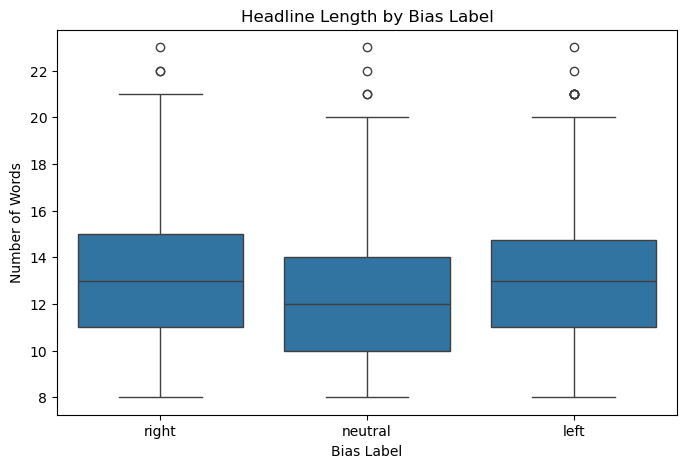

In [61]:
#3.2 Headline Length Analysis
df["headline_length"] = df["headline"].str.split().str.len()

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="headline_length"
)

plt.title("Headline Length by Bias Label")
plt.xlabel("Bias Label")
plt.ylabel("Number of Words")

plt.show()

In [53]:
df.groupby("label")["headline_length"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
label,,,,,
left,1654,12.77,13.0,8,23
neutral,1658,12.44,12.0,8,23
right,1654,12.79,13.0,8,23


In [63]:
#3.3 Text Preprocessing for Word-Level EDA
import re
from collections import Counter

# Stopwords
stop_words = {
    "the", "a", "an", "and", "or", "but", "to", "of", "in", "on",
    "for", "with", "at", "by", "from", "as", "is", "are", "was",
    "were", "be", "been", "this", "that", "these", "those", "it",
    "its", "after", "before", "during", "into", "over", "under",
    "their", "they", "them", "will", "has", "have", "had"
}

def clean_for_eda(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return words

df["eda_tokens"] = df["headline"].apply(clean_for_eda)

In [65]:
#3.4 Most Frequent Words Overall
all_words = [
    word
    for tokens in df["eda_tokens"]
    for word in tokens
]

word_counts = Counter(all_words)

top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "frequency"]
)

top_words

,word,frequency
0,plan,967
1,state,722
2,year,669
3,officials,563
4,public,525
5,department,412
6,across,382
7,agency,364
8,committee,363
9,says,362


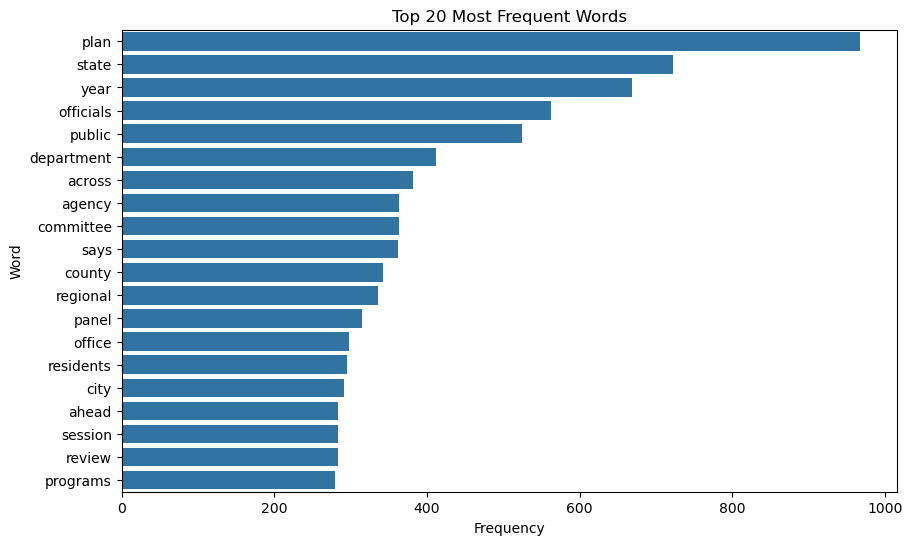

In [67]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_words,
    x="frequency",
    y="word"
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [69]:
#3.5 Word Associations by Bias Label
label_word_counts = {}

for label in ["left", "neutral", "right"]:
    words = [
        word
        for tokens in df[df["label"] == label]["eda_tokens"]
        for word in tokens
    ]
    
    label_word_counts[label] = Counter(words)

In [71]:
for label, counts in label_word_counts.items():
    print(f"\nTop words associated with {label.upper()} headlines:")
    
    for word, count in counts.most_common(15):
        print(f"{word:<20} {count}")


Top words associated with LEFT headlines:
plan                 312
public               248
year                 228
state                220
programs             201
officials            185
department           139
across               131
county               129
services             127
protections          123
committee            109
safety               108
agency               106
panel                104

Top words associated with NEUTRAL headlines:
plan                 315
state                259
schedules            238
year                 217
procedures           212
officials            188
says                 152
public               137
department           136
review               133
agency               131
reporting            130
committee            128
regional             128
rules                124

Top words associated with RIGHT headlines:
plan                 340
state                243
year                 224
officials            190
tax              

In [73]:
df.drop(columns=["headline_length", "eda_tokens"], inplace=True)

In [75]:
df.to_csv("media_bias_headlines_cleaned.csv", index=False)

## 4. Text Preprocessing

Text preprocessing prepares the news headlines for NLP models.

The preprocessing stage includes:
- Converting text to lowercase
- Removing unnecessary punctuation and special characters
- Normalizing whitespace
- Preserving the semantic content of the headline

The cleaned text will later be used for SBERT embeddings and Transformer-based classification.

In [80]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_headline"] = df["headline"].apply(clean_text)

# Encode labels
label_map = {"left": 0, "neutral": 1, "right": 2}
df["label_id"] = df["label"].map(label_map)

df[["headline", "clean_headline", "label", "label_id"]].head()

,headline,clean_headline,label,label_id
0,An international panel to fund sovereignty safeguards in international agreements at a Brussels conference,an international panel to fund sovereignty safeguards in international agreements at a brussels conference,right,2
1,The food safety agency to audit agricultural census methods as the fiscal year begins,the food safety agency to audit agricultural census methods as the fiscal year begins,neutral,1
2,Free legal clinics debated by the mayor's office this winter,free legal clinics debated by the mayor s office this winter,left,0
3,The homeland security department to renew cooperation agreements between local police and federal agents in Seattle,the homeland security department to renew cooperation agreements between local police and federal agents in seattle,right,2
4,A city council member says the transportation agency will reduce bus route timetables in the coming fiscal year,a city council member says the transportation agency will reduce bus route timetables in the coming fiscal year,neutral,1


## 5. SBERT Embeddings

Sentence-BERT (SBERT) is used to convert each news headline into a numerical vector that captures its semantic meaning. These embeddings will be used for classification and later stored in a vector database for similarity search.

In [86]:
!pip install -U sentence-transformers

In [90]:
from sentence_transformers import SentenceTransformer

sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [85]:
embeddings = sbert_model.encode(
    df["clean_headline"].tolist(),
    show_progress_bar=True
)

print("Embedding shape:", embeddings.shape)

Batches:   0%|          | 0/156 [00:00<?, ?it/s]

Embedding shape: (4966, 384)


## 6. Vector Database with FAISS

The SBERT embeddings are stored in a FAISS vector index to enable efficient semantic similarity search. This allows the system to retrieve news headlines that are similar to a given headline.

In [93]:
!pip install -U faiss-cpu

   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   ------ --------------------------------- 2.6/16.3 MB 15.0 MB/s eta 0:00:01
   ---------------- ----------------------- 6.6/16.3 MB 16.8 MB/s eta 0:00:01
   -------------------------- ------------- 10.7/16.3 MB 18.6 MB/s eta 0:00:01
   ------------------------------ --------- 12.6/16.3 MB 16.4 MB/s eta 0:00:01
   ---------------------------------- ----- 13.9/16.3 MB 14.1 MB/s eta 0:00:01
   ---------------------------------------  16.3/16.3 MB 13.3 MB/s eta 0:00:01
   ---------------------------------------- 16.3/16.3 MB 13.0 MB/s eta 0:00:00


In [95]:
import faiss
import numpy as np

# Convert embeddings to FAISS-compatible format
embedding_matrix = np.asarray(embeddings, dtype="float32")

# Create FAISS index using cosine similarity
faiss.normalize_L2(embedding_matrix)
index = faiss.IndexFlatIP(embedding_matrix.shape[1])

# Add embeddings to the index
index.add(embedding_matrix)

print("FAISS index created successfully!")
print("Number of vectors:", index.ntotal)
print("Vector dimension:", index.d)

FAISS index created successfully!
Number of vectors: 4966
Vector dimension: 384


In [97]:
query = "Government increases support for low income families"

query_embedding = sbert_model.encode([query]).astype("float32")
faiss.normalize_L2(query_embedding)

distances, indices = index.search(query_embedding, k=5)

print("Query:", query)
print("\nMost similar headlines:\n")

for rank, idx in enumerate(indices[0], 1):
    print(f"{rank}. {df.iloc[idx]['headline']}")
    print(f"   Label: {df.iloc[idx]['label']}")
    print(f"   Similarity: {distances[0][rank-1]:.4f}\n")

Query: Government increases support for low income families

Most similar headlines:

1. A poll of 600 residents reports growing public support for income tax relief for families
   Label: right
   Similarity: 0.6935

2. Will state housing officials boost housing vouchers for low-income families for about 170,000 residents?
   Label: left
   Similarity: 0.6476

3. The revenue agency to weigh tax credits for low-income families
   Label: left
   Similarity: 0.6293

4. Family services hotlines increased by a welfare reform panel
   Label: neutral
   Similarity: 0.6195

5. A senior state official says a welfare reform panel will curb child care subsidies for families ahead of the spring session
   Label: left
   Similarity: 0.6115



## 7. Baseline Classification with Scikit-learn

A Logistic Regression classifier is trained using the SBERT embeddings as a baseline model. Its performance will later be compared with the fine-tuned Transformer.

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    embeddings,
    df["label_id"],
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"]
)

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["left", "neutral", "right"]
))

Accuracy: 0.7928

Classification Report:
              precision    recall  f1-score   support

        left       0.78      0.75      0.76       331
     neutral       0.85      0.88      0.86       332
       right       0.75      0.76      0.75       331

    accuracy                           0.79       994
   macro avg       0.79      0.79      0.79       994
weighted avg       0.79      0.79      0.79       994



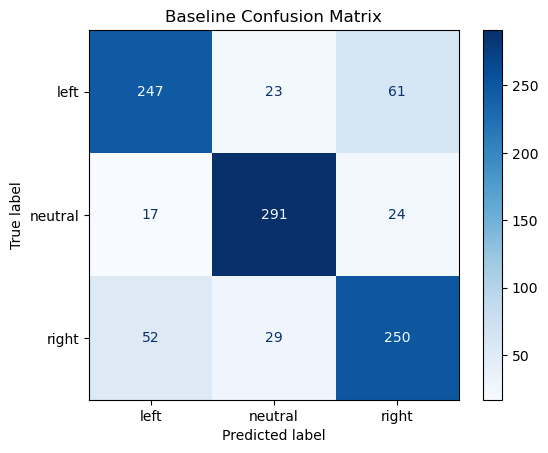

In [102]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["left", "neutral", "right"],
    cmap="Blues"
)

plt.title("Baseline Confusion Matrix")
plt.show()

Phase 7 — HuggingFace Transformer Fine-tuning.

In [105]:
!pip install -U transformers datasets accelerate

   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 559.1/559.1 kB 6.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/28.0 MB ? eta -:--:--
   ---- ----------------------------------- 3.1/28.0 MB 15.4 MB/s eta 0:00:02
   --------- ------------------------------ 6.6/28.0 MB 15.5 MB/s eta 0:00:02
   -------------- ------------------------- 10.2/28.0 MB 16.8 MB/s eta 0:00:02
   ------------------ --------------------- 12.6/28.0 MB 16.1 MB/s eta 0:00:01
   --------------------- ------------------ 15.2/28.0 MB 14.5 MB/s eta 0:00:01
   ------------------------ --------------- 17.0/28.0 MB 13.9 MB/s eta 0:00:01
   -------------------------- ------------- 18.4/28.0 MB 12.9 MB/s eta 0:00:01
   ---------------------------- ----------- 19.7/28.0 MB 11.8 MB/s eta 0:00:01
   ------------------------------ --------- 21.2/28.0 MB 11.4 MB/s eta 0:00:01
   --------------------------------- ------ 23.1/28.0 MB 11.0 MB/s eta

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.33.2 which is incompatible.


In [109]:
# 7.2 — Prepare train/validation/test data

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df[["headline", "label_id"]],
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df["label_id"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 3574
Validation: 398
Test: 994


In [111]:
# 7.3 — Tokenization

from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_text(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors="pt"
    )

train_tokens = tokenize_text(train_df["headline"])
val_tokens = tokenize_text(val_df["headline"])
test_tokens = tokenize_text(test_df["headline"])

print("Tokenization completed.")
print("Train token shape:", train_tokens["input_ids"].shape)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

C:\Users\Arpitha\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Arpitha\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenization completed.
Train token shape: torch.Size([3574, 28])


In [113]:
# 7.4 — Create PyTorch datasets

import torch
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(
    train_tokens["input_ids"],
    train_tokens["attention_mask"],
    torch.tensor(train_df["label_id"].values)
)

val_dataset = TensorDataset(
    val_tokens["input_ids"],
    val_tokens["attention_mask"],
    torch.tensor(val_df["label_id"].values)
)

test_dataset = TensorDataset(
    test_tokens["input_ids"],
    test_tokens["attention_mask"],
    torch.tensor(test_df["label_id"].values)
)

print("PyTorch datasets created.")
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

PyTorch datasets created.
Train samples: 3574
Validation samples: 398
Test samples: 994


In [115]:
# 7.5 — Load DistilBERT

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label={
        0: "left",
        1: "neutral",
        2: "right"
    },
    label2id={
        "left": 0,
        "neutral": 1,
        "right": 2
    }
)

print("DistilBERT model loaded successfully.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully.


In [119]:
# 7.6 — Transformer training setup

from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16
)

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Device:", device)
print("Training setup completed.")

Device: cpu
Training setup completed.


In [121]:
# 7.7 — Train DistilBERT

from tqdm.auto import tqdm

epochs = 2

for epoch in range(epochs):
    model.train()
    total_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}")

    for input_ids, attention_mask, labels in progress_bar:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch + 1} completed — Average Loss: {avg_loss:.4f}")

Epoch 1/2:   0%|          | 0/224 [00:00<?, ?it/s]

Epoch 1 completed — Average Loss: 0.5976


Epoch 2/2:   0%|          | 0/224 [00:00<?, ?it/s]

Epoch 2 completed — Average Loss: 0.0941


In [123]:
# 7.8 — Evaluate DistilBERT on the test set

from sklearn.metrics import accuracy_score, classification_report
import torch

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for input_ids, attention_mask, labels in test_dataset:
        input_ids = input_ids.unsqueeze(0).to(device)
        attention_mask = attention_mask.unsqueeze(0).to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        prediction = torch.argmax(outputs.logits, dim=1).item()

        all_predictions.append(prediction)
        all_labels.append(labels.item())

accuracy = accuracy_score(all_labels, all_predictions)

print("Transformer Accuracy:", round(accuracy, 4))
print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_predictions,
    target_names=["left", "neutral", "right"]
))

Transformer Accuracy: 0.9859

Classification Report:
              precision    recall  f1-score   support

        left       0.99      0.97      0.98       331
     neutral       0.98      1.00      0.99       332
       right       0.99      0.99      0.99       331

    accuracy                           0.99       994
   macro avg       0.99      0.99      0.99       994
weighted avg       0.99      0.99      0.99       994



Phase 8 — Prediction + Similar Headline Retrieval

We'll create one simple demo cell where you can enter any headline and get:

Predicted bias: Left / Neutral / Right
Confidence: model probability
Similar headlines: retrieved from our FAISS vector database
Their existing labels

In [126]:
# 8.1 — Headline prediction + FAISS retrieval

import numpy as np
import torch

label_names = ["left", "neutral", "right"]

def predict_headline(headline):
    # Tokenize input
    tokens = tokenizer(
        headline,
        return_tensors="pt",
        truncation=True,
        max_length=64
    )

    tokens = {key: value.to(device) for key, value in tokens.items()}

    # Transformer prediction
    model.eval()

    with torch.no_grad():
        outputs = model(**tokens)
        probabilities = torch.softmax(outputs.logits, dim=1)[0]

    predicted_id = torch.argmax(probabilities).item()

    print("Headline:", headline)
    print("Predicted Bias:", label_names[predicted_id])
    print("Confidence:", f"{probabilities[predicted_id].item():.2%}")

    # FAISS semantic retrieval
    query_embedding = sbert_model.encode([headline]).astype("float32")
    faiss.normalize_L2(query_embedding)

    distances, indices = index.search(query_embedding, k=3)

    print("\nSimilar Headlines:")
    
    for rank, idx in enumerate(indices[0], 1):
        print(f"{rank}. {df.iloc[idx]['headline']}")
        print(f"   Label: {df.iloc[idx]['label']}")
        print(f"   Similarity: {distances[0][rank-1]:.4f}")


# Try a new headline
predict_headline(
    "Government announces new support program for low income families"
)

Headline: Government announces new support program for low income families
Predicted Bias: left
Confidence: 99.17%

Similar Headlines:
1. Child care subsidies for families reviewed by a welfare reform panel in the coming fiscal year
   Label: left
   Similarity: 0.6442
2. The family services office renewed eligibility checks for benefit programs
   Label: right
   Similarity: 0.6346
3. A poll of 600 residents reports growing public support for income tax relief for families
   Label: right
   Similarity: 0.6252


In [138]:
# Test the model with new headlines from all three classes

test_headlines = [
    # LEFT-style
    "Government expands public healthcare and housing support for low income families",
    "New policy strengthens worker protections and increases funding for social programs",
    "Officials announce expanded childcare assistance for working families",

    # NEUTRAL-style
    "Government releases annual report on education spending and enrollment",
    "Officials announce updated procedures for regional transport services",
    "The department publishes new guidelines for public sector reporting",

    # RIGHT-style
    "Government proposes tax cuts to encourage private investment and business growth",
    "Officials announce plans to reduce regulations on small businesses",
    "New policy focuses on lower taxes and limiting government spending"
]

for headline in test_headlines:
    tokens = tokenizer(
        headline,
        return_tensors="pt",
        truncation=True,
        max_length=64
    )

    tokens = {key: value.to(device) for key, value in tokens.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**tokens)
        probabilities = torch.softmax(outputs.logits, dim=1)[0]

    predicted_id = torch.argmax(probabilities).item()

    print("-" * 80)
    print("Headline:", headline)
    print("Predicted:", label_names[predicted_id])
    print("Confidence:", f"{probabilities[predicted_id].item():.2%}")

--------------------------------------------------------------------------------
Headline: Government expands public healthcare and housing support for low income families
Predicted: left
Confidence: 99.17%
--------------------------------------------------------------------------------
Headline: New policy strengthens worker protections and increases funding for social programs
Predicted: left
Confidence: 99.07%
--------------------------------------------------------------------------------
Headline: Officials announce expanded childcare assistance for working families
Predicted: left
Confidence: 99.12%
--------------------------------------------------------------------------------
Headline: Government releases annual report on education spending and enrollment
Predicted: neutral
Confidence: 51.71%
--------------------------------------------------------------------------------
Headline: Officials announce updated procedures for regional transport services
Predicted: neutral
Confide

In [140]:
# Real-world headline test
# These are real published headlines, not from our synthetic dataset.

real_headlines = [
    "US Treasury's Bessent, China's He to launch talks on AI, trade, critical minerals",
    "World leaders return to UN amid wars in Middle East and Ukraine",
    "China's CXMT says new memory-chip platform enters mass production",
    "India's Tata reappoints chairman, backs listing in rift with controlling charity",
    "India warns new US tariffs over Russian oil may hit ties, vows to protect energy security",
    "China keeps benchmark lending rates unchanged for 16th month in September",
    "Apple's Tim Cook sees Australia's social media curbs as world-leading, PM says",
    "Pharma sector doubles down on AI to slash costs, timelines",
    "Canada optimistic about concluding trade talks with India by year-end"
]

print("=" * 100)
print("REAL-WORLD HEADLINE TEST")
print("=" * 100)

for i, headline in enumerate(real_headlines, 1):

    tokens = tokenizer(
        headline,
        return_tensors="pt",
        truncation=True,
        max_length=64
    )

    tokens = {key: value.to(device) for key, value in tokens.items()}

    model.eval()

    with torch.no_grad():
        outputs = model(**tokens)
        probabilities = torch.softmax(outputs.logits, dim=1)[0]

    predicted_id = torch.argmax(probabilities).item()

    print(f"\n{i}. {headline}")
    print(f"   Prediction: {label_names[predicted_id]}")
    print(f"   Confidence: {probabilities[predicted_id].item():.2%}")

REAL-WORLD HEADLINE TEST

1. US Treasury's Bessent, China's He to launch talks on AI, trade, critical minerals
   Prediction: right
   Confidence: 95.50%

2. World leaders return to UN amid wars in Middle East and Ukraine
   Prediction: left
   Confidence: 94.64%

3. China's CXMT says new memory-chip platform enters mass production
   Prediction: right
   Confidence: 89.24%

4. India's Tata reappoints chairman, backs listing in rift with controlling charity
   Prediction: right
   Confidence: 97.36%

5. India warns new US tariffs over Russian oil may hit ties, vows to protect energy security
   Prediction: right
   Confidence: 99.24%

6. China keeps benchmark lending rates unchanged for 16th month in September
   Prediction: right
   Confidence: 96.54%

7. Apple's Tim Cook sees Australia's social media curbs as world-leading, PM says
   Prediction: left
   Confidence: 63.46%

8. Pharma sector doubles down on AI to slash costs, timelines
   Prediction: right
   Confidence: 98.38%

9. Ca

In [146]:
test_headlines = [
    "Government is planning to spend heavily on infrastructure budget"
]

for headline in test_headlines:
    tokens = tokenizer(
        headline,
        return_tensors="pt",
        truncation=True,
        max_length=64
    )

    tokens = {key: value.to(device) for key, value in tokens.items()}

    model.eval()

    with torch.no_grad():
        outputs = model(**tokens)
        probabilities = torch.softmax(outputs.logits, dim=1)[0]

    predicted_id = torch.argmax(probabilities).item()

    print("Headline:", headline)
    print("Predicted:", label_names[predicted_id])
    print("Confidence:", f"{probabilities[predicted_id].item():.2%}")
    print("-" * 80)

Headline: Government is planning to spend heavily on infrastructure budget
Predicted: right
Confidence: 98.94%
--------------------------------------------------------------------------------


## 9. Model Performance Comparison

Two classification approaches were evaluated for the media bias detection task.

- **Baseline:** SBERT embeddings with Logistic Regression
- **Transformer:** Fine-tuned DistilBERT

The baseline provides a simple reference point, while the Transformer directly learns contextual patterns from the news headlines.

In [131]:
results = {
    "Model": ["SBERT + Logistic Regression", "DistilBERT"],
    "Accuracy": [0.7928, 0.9859]
}

import pandas as pd

pd.DataFrame(results)

,Model,Accuracy
0,SBERT + Logistic Regression,0.7928
1,DistilBERT,0.9859


## 10. Results

The SBERT + Logistic Regression baseline achieved an accuracy of **79.28%** on the test set.

The fine-tuned DistilBERT model achieved an accuracy of **98.59%** on the test set.

The Transformer therefore learned the predefined patterns in the synthetic dataset more effectively than the baseline model.

The class-wise F1-scores for DistilBERT were:

- **Left:** 0.98
- **Neutral:** 0.99
- **Right:** 0.99

These results demonstrate strong performance on the synthetic benchmark dataset. However, they should not be interpreted as equivalent performance on real-world news because the dataset was synthetically generated using predefined framing patterns.

## 11. Vector Database Component

FAISS was used as a lightweight local vector database for semantic similarity search.

SBERT converts each headline into a 384-dimensional embedding. These embeddings are stored in a FAISS index.

For a new headline, its SBERT embedding is compared with the stored embeddings to retrieve semantically similar headlines.

The Vector DB is used for **retrieval**, not for bias classification.

Therefore:

- **DistilBERT → predicts the bias category**
- **SBERT + FAISS → retrieves semantically similar headlines**

The retrieved headlines may have different bias labels because semantic similarity and bias classification are different tasks.

## 12. Final Prediction Demo

The completed system accepts a new news headline and performs two operations:

1. Predicts whether the headline follows the predefined **left, neutral, or right framing category** using the fine-tuned DistilBERT model.
2. Retrieves the most semantically similar headlines from the FAISS vector database.

Example:

**Input:**  
"Government announces new support program for low income families"

**Predicted Bias:** Left

**Confidence:** 99.17%

The retrieved headlines demonstrate semantic similarity independently of the predicted bias category.

## 13. Limitations

- The dataset used in this project is synthetically generated and does not represent a real-world news corpus.
- The labels are based on predefined framing patterns and should not be considered objective political truth.
- The high Transformer accuracy may partly reflect consistent patterns present in the synthetic dataset.
- Real-world media bias can involve more complex factors than headline text alone.
- Political framing may vary across sources, topics, regions, and time periods.
- FAISS provides semantic similarity retrieval and does not determine whether a headline is left-leaning, neutral, or right-leaning.

## 14. Conclusion

This project developed a complete prototype for classifying news headlines into three predefined framing categories: **left, neutral, and right**.

The workflow combined:

- Text preprocessing
- Exploratory Data Analysis
- SBERT embeddings
- Scikit-learn classification
- FAISS vector similarity search
- HuggingFace DistilBERT fine-tuning

The SBERT + Logistic Regression model provided a baseline accuracy of **79.28%**, while the fine-tuned DistilBERT model achieved **98.59%** accuracy on the synthetic test dataset.

The project also demonstrates how a Transformer can be combined with a vector database to provide both **classification and semantic retrieval** capabilities.

The results establish a working prototype while highlighting the need for real-world, human-annotated datasets for meaningful evaluation of media bias detection.